# Deep Learning Foundations: Multilayer Perceptrons (MLP) and Loss Mechanics

[Click here to access notebook on single-neuron fundamentals](1_perceptron.ipynb).

Building on single-neuron fundamentals, this notebook maps out the transition to Multilayer Perceptrons (MLPs). Stacking layers expands a network's computational capability, shifting from simple linear approximations to complex non-linear classification systems necessary for complex modern architectures problems.

--- 
## 1. Detailed Anatomy of an MLP

A single neuron draws a single line. A Multilayer Perceptron (MLP) draws a complex, non-linear boundary by stacking those lines, passing them through activation functions, and layering them sequentially. This architecture consists of three distinct types of layers:

1. **The Input Layer ($l=0$):** This layer does no processing. It acts as a conduit to receive raw features (e.g., pixels of an image, or encoded tokens in a sentence). For instance, if we are classifying a $28 \times 28$ pixel image, this layer consists of exactly 784 passive input nodes that simply pass numerical values forward.

2. **The Hidden Layers:** This is where abstract features are extracted through a process of geometric space warping. 
   * **Hierarchical Feature Extraction:** A deep neural network can contain numerous hidden layers operating in a pipeline. The first hidden layer handles raw inputs to isolate primitive elements (e.g., simple linear gradients or basic edges). The second layer treats those edge-detections as inputs, combining them into intermediate shapes (like a curve or an ear). A third layer can synthesize those shapes to recognize a complex object (like a cat).
   * **The Mechanism of Space Warping:** Each individual hidden neuron maintains its own unique weight vector and bias parameter, meaning each neuron searches for a completely different feature pattern. While a single neuron can only draw a straight boundary, the network passes these linear combinations through a non-linear activation function (like ReLU). The activation function acts as a coordinate folding mechanism—it chops off or bends the negative spaces. Subsequent hidden layers draw new straight lines across this already-bent space. When this final, multi-layered decision boundary is projected back onto the original raw input space, it manifests as a highly complex, curved, and intricate boundary capable of solving non-linear problems like XOR [see previous notebook here](1_perceptron.ipynb).

3. **The Output Layer:** The final layer that maps the highly abstracted hidden representations to a final prediction. 
   * For binary classification (e.g., Cat vs. Dog), a single neuron using a Sigmoid function outputs a single scalar value between 0 and 1, representing a probability. 
   * For a multiclass objective [(like the 1,000-class ImageNet challenge)](https://en.wikipedia.org/wiki/ImageNet), this layer contains a dedicated neuron for each class, evaluated using a Softmax function to produce a valid probability distribution across all categories.

![MLP - Multiple Layer Perceptron](https://miro.medium.com/v2/resize:fit:720/format:webp/1*-IPQlOd46dlsutIbUq1Zcw.png)

--- 
## 2. Forward Propagation

Forward propagation is the process of moving data linearly forward from input to output, layer by layer, in a single sequential pass. This step is **purely dedicated to inference (making a guess)**; no weight adjustment or learning occurs during this phase.

### The Lifecycle of Data During the Forward Pass
Using $l$ to index layers and indices $i, j$ for individual neurons, we trace the forward transformation:

* **Layer 0 (Inputs):** The initial input vector is denoted as $a^{(0)}$ (activations of layer 0). For standard binary logic operations, this vector represents $a^{(0)} = [x_1, x_2]$.
* **Transition from Layer $l$ to Layer $l+1$:** For every single neuron $j$ in the receiving layer $l+1$, two distinct operations take place:
    1. **The Linear Step (Weighted Sum):** Neuron $j$ evaluates all upstream activations ($a_i^{(l)}$) from the previous layer $l$. It multiplies each incoming activation by its corresponding weight ($w_{ji}^{(l+1)}$), sums the products, and appends its internal bias ($b_j^{(l+1)}$) to establish a pre-activation sum $z_j^{(l+1)}$:
    $$z_j^{(l+1)} = \sum_{i} (a_i^{(l)} \cdot w_{ji}^{(l+1)}) + b_j^{(l+1)}$$
    2. **The Non-Linear Step (Activation):** The neuron maps that pre-activation value $z$ through a non-linear activation function ($f$) such as ReLU, Sigmoid, or Tanh. This produces the final activation vector element ($a_j^{(l+1)}$) for that specific node:
    $$a_j^{(l+1)} = f(z_j^{(l+1)})$$

This cycle repeats sequentially. The activations of the current hidden layer ($a^{(l+1)}$) serve as the input nodes for the subsequent layer until the data arrives at the final **Output Layer**. The final evaluations represent the network's system prediction (denoted as $\hat{y}$ or $h_\theta(x)$).

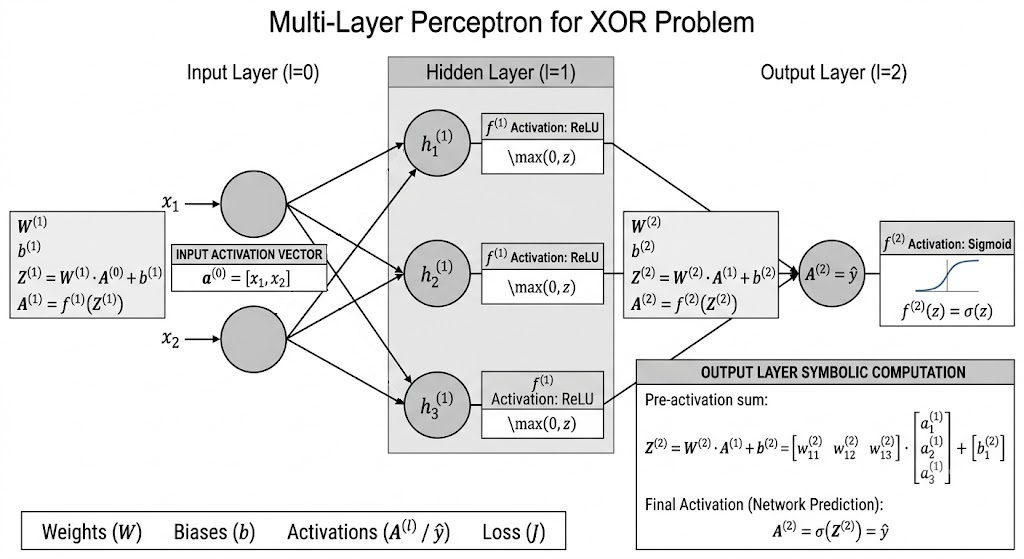


--- 
## 3. The Math: Hidden Layer Matrix Transformations

Computing calculations node-by-node using standard nested loops is computationally inefficient. To process thousands of features in parallel, modern models rely heavily on matrix operations, which match the core processing strengths of GPUs.

### Formalizing Matrix Notation
* Let $L$ be the total number of layers within the system (including the input layer).
* Let $n^{[l]}$ denote the exact number of neurons present in layer $l$.

We can structure weights and biases into compact matrices for any destination layer $l+1$:

* **Weight Matrix ($W^{[l+1]}$):** This matrix maps incoming activations from layer $l$ to the pre-activations of layer $l+1$. Its dimensions are strictly $(n^{[l+1]}, n^{[l]})$. If Hidden Layer 1 has 4 neurons and Input Layer 0 has 3 features, $W^{[1]}$ is a $(4 \times 3)$ matrix:
$$W^{[l+1]} = \begin{bmatrix} w_{11} & w_{12} & w_{13} \\ w_{21} & w_{22} & w_{23} \\ w_{31} & w_{32} & w_{33} \\ w_{41} & w_{42} & w_{43} \end{bmatrix}$$
*Crucially, the rows match the destination layer count $n^{[l+1]}$, while the columns align with the source layer feature count $n^{[l]}$.* It means that, **each single neroun carries three weights**: *one for each feature*. Therefore, each neroun $j$ in layer $(l+1)$ has its own vector of weights of demension $n^{[l]}$.

*Therefore, the set of neroun $W$ is represented by the rows. The set of feature $X$ is represented by the columns. Thus, the value in $w_{23}$ is the weight for neuron $2$, feature $3$. Similarly, $w_{42}$, the weight for neuron $4$, feature $2$.*

* **Bias Vector ($b^{[l+1]}$):** A simple column vector housing the specific scalar bias term for every neuron in the destination layer. It maintains the dimensions $(n^{[l+1]}, 1)$:
$$b^{[1]} = \begin{bmatrix} b_1 \\ b_2 \\ b_3 \\ b_4 \end{bmatrix}$$

* **Activation Vector ($a^{[l]}$):** A column vector holding the inputs passed forward from the preceding layer, keeping the dimensional shape $(n^{[l]}, 1)$.

### Bridging Neurons to the Matrix Structure
While each neuron maintains an independent weight vector, they pack cleanly together. For an input layer with 2 features ($x_1, x_2$) and a hidden layer with 3 neurons, each neuron evaluates a distinct pattern:
* Neuron 1 Weight Vector: $\vec{w}_1 = [0.1, -0.5]$
* Neuron 2 Weight Vector: $\vec{w}_2 = [0.2, 0.3]$
* Neuron 3 Weight Vector: $\vec{w}_3 = [-0.1, 0.8]$

Stacking these row vectors on top of each other constructs our layer weight matrix:
$$W = \begin{bmatrix} \leftarrow & \vec{w}_1 & \rightarrow \\ \leftarrow & \vec{w}_2 & \rightarrow \\ \leftarrow & \vec{w}_3 & \rightarrow \end{bmatrix} = \begin{bmatrix} 0.1 & -0.5 \\ 0.2 & 0.3 \\ -0.1 & 0.8 \end{bmatrix}$$

When computing $Z = W \cdot X + b$, the linear algebra expands parallel calculations across each row automatically:
$$Z = \begin{bmatrix} 0.1 & -0.5 \\ 0.2 & 0.3 \\ -0.1 & 0.8 \end{bmatrix} \cdot \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \begin{bmatrix} b_1 \\ b_2 \\ b_3 \end{bmatrix}$$
$$\text{Neuron 1: } z_1 = (0.1 \cdot x_1) + (-0.5 \cdot x_2) + b_1$$
$$\text{Neuron 2: } z_2 = (0.2 \cdot x_1) + (0.3 \cdot x_2) + b_2$$
$$\text{Neuron 3: } z_3 = (-0.1 \cdot x_1) + (0.8 \cdot x_2) + b_3$$

### Vectorized Mathematical Step
Using vector mathematics, we perform the linear pass across an entire layer simultaneously:
$$Z^{[l+1]} = W^{[l+1]} \cdot a^{[l]} + b^{[l+1]}$$
$$\text{Dimensional Check: } (3 \times 2) \cdot (2 \times 1) \rightarrow (3 \times 1) + (3 \times 1) \rightarrow (3 \times 1)$$

* That's for a layer with 3 nerouns and two activation (previous layer). 

Next, we compute the non-linear transformation element-wise:
$$A^{[l+1]} = f(Z^{[l+1]})$$

#### Trace Example:
Given $a^{[0]} = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$, $W^{[1]} = \begin{bmatrix} 0.1 & -0.5 \\ 0.2 & 0.3 \\ -0.1 & 0.8 \end{bmatrix}$, and $b^{[1]} = \begin{bmatrix} -0.1 \\ 0.1 \\ -0.2 \end{bmatrix}$:
$$Z^{[1]} = \begin{bmatrix} 0.1 & -0.5 \\ 0.2 & 0.3 \\ -0.1 & 0.8 \end{bmatrix} \cdot \begin{bmatrix} 1 \\ 0 \end{bmatrix} + \begin{bmatrix} -0.1 \\ 0.1 \\ -0.2 \end{bmatrix} = \begin{bmatrix} 0.1 \\ 0.2 \\ -0.1 \end{bmatrix} + \begin{bmatrix} -0.1 \\ 0.1 \\ -0.2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0.3 \\ -0.3 \end{bmatrix}$$

Applying an element-wise ReLU function ($\max(0, z)$) yields the hidden activation vector:
$$A^{[1]} = \begin{bmatrix} \max(0, 0) \\ \max(0, 0.3) \\ \max(0, -0.3) \end{bmatrix} = \begin{bmatrix} 0 \\ 0.3 \\ 0 \end{bmatrix}$$

This vector $A^{[1]}$ is passed to the output layer parameters ($W^{[2]}, b^{[2]}$) to calculate the network's final classification scalar prediction $\hat{y}$ ($A^{[2]}$).

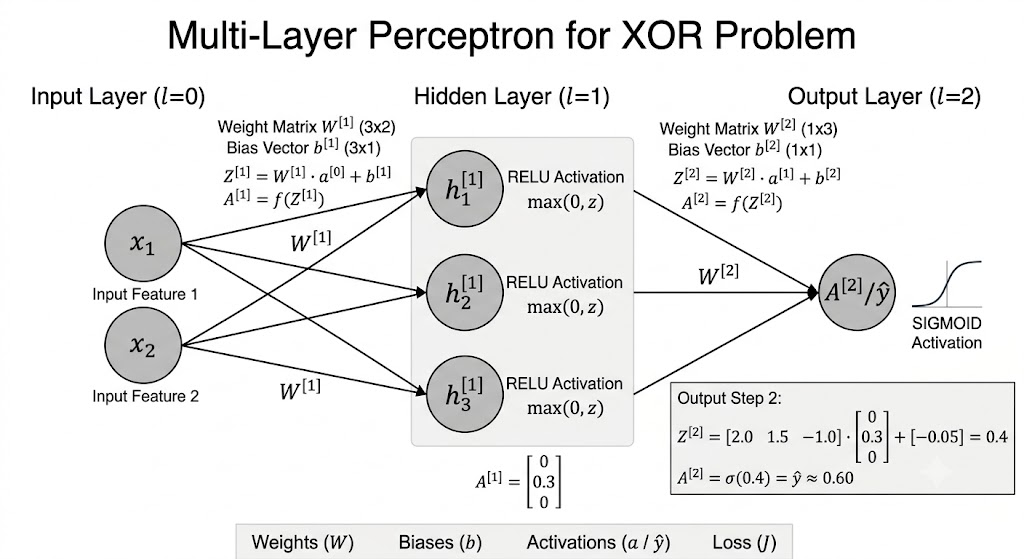

--- 
## 4. Loss Functions and Binary Cross-Entropy (BCE)

Once an output layer produces a prediction vector ($A^{[L]}$), we must evaluate its performance using a **Loss Function** ($J$). A loss function maps network estimations ($\hat{y}$) against ground-truth labels ($y$) to generate a single scalar value representing the performance penalty.

For regression scenarios, **Mean Squared Error (MSE)** is commonly used:
$$MSE = \frac{1}{2} (\hat{y} - y)^2$$

For classification scenarios where the output layer is bounded between 0 and 1 via a Sigmoid function, **Binary Cross-Entropy (BCE)** is the mathematical standard:
$$L(\hat{y}, y) = - \left( y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right)$$

### Understanding the Information Theory Behind BCE
To understand why it is called **Binary Cross-Entropy**, we look to the concept of **Entropy** in information theory, pioneered by Claude Shannon. In simple terms, entropy measures the average uncertainty or surprise in a system. If an event is 100% certain to happen, its entropy is zero because there is no surprise.

When training a classifier, we look at two distinct probability distributions:
1. **The True Distribution ($y$):** The actual ground-truth label ($y=1$ or $y=0$). This is the absolute truth, representing a system with zero uncertainty.
2. **The Predicted Distribution ($\hat{y}$):** The probability calculated by our neural network (e.g., $\hat{y}=0.75$).

**Cross-Entropy** measures the average number of bits needed to identify an event from a target distribution if we use a coding scheme optimized for a *predicted* distribution rather than the *true* one. In plain language, it measures how much extra "surprise" we experience because our network's predictions do not perfectly match the absolute truth. The word *Binary* simply indicates we are evaluating two possible classes (0 or 1). 

*[Click here for a more detailed explanation on cross-entropy](21_cross-entropy_loss.md)*.

### The Mathematical Mechanics of the BCE Equation
The equation changes based on the value of the ground truth label:

* **Case 1: The True Label is $y = 1$**

  When $y=1$, the second term $(1 - y)$ becomes exactly $0$, dropping out of the calculation. We are left with:
  $$L(\hat{y}, 1) = -\log(\hat{y})$$
  * If the network predicts confidently and correctly ($\hat{y} = 0.99$), $-\log(0.99) \approx 0.01$, resulting in a minimal loss penalty.
  * If the network predicts confidently but incorrectly ($\hat{y} = 0.01$), $-\log(0.01) \approx 4.6$, causing the loss curve to shoot sharply upward toward infinity.

* **Case 2: The True Label is $y = 0$**

  When $y=0$, the first term component drops out. We are left with:
  $$L(\hat{y}, 0) = -\log(1 - \hat{y})$$
  This relationship mirrors Case 1, but heavily penalizes any predictions that approach `1` when the target is `0`.

---
## 5. Backpropagation: How Neural Networks Learn from Their Mistakes

Before understanding Gradient Descent, it is necessary to understand the mechanism that makes learning possible inside a neural network: **Backpropagation**.

Forward propagation allows the network to make predictions. Backpropagation performs the opposite operation: it examines the prediction error and systematically traces that error backward through the network to determine how every parameter contributed to the mistake.

Backpropagation can be understood as the network’s feedback mechanism.

Its objective is to compute the **gradient of the Loss Function with respect to every weight and bias** in the model. These gradients become instructions that indicate:

> *How much should each parameter change to reduce future error?*

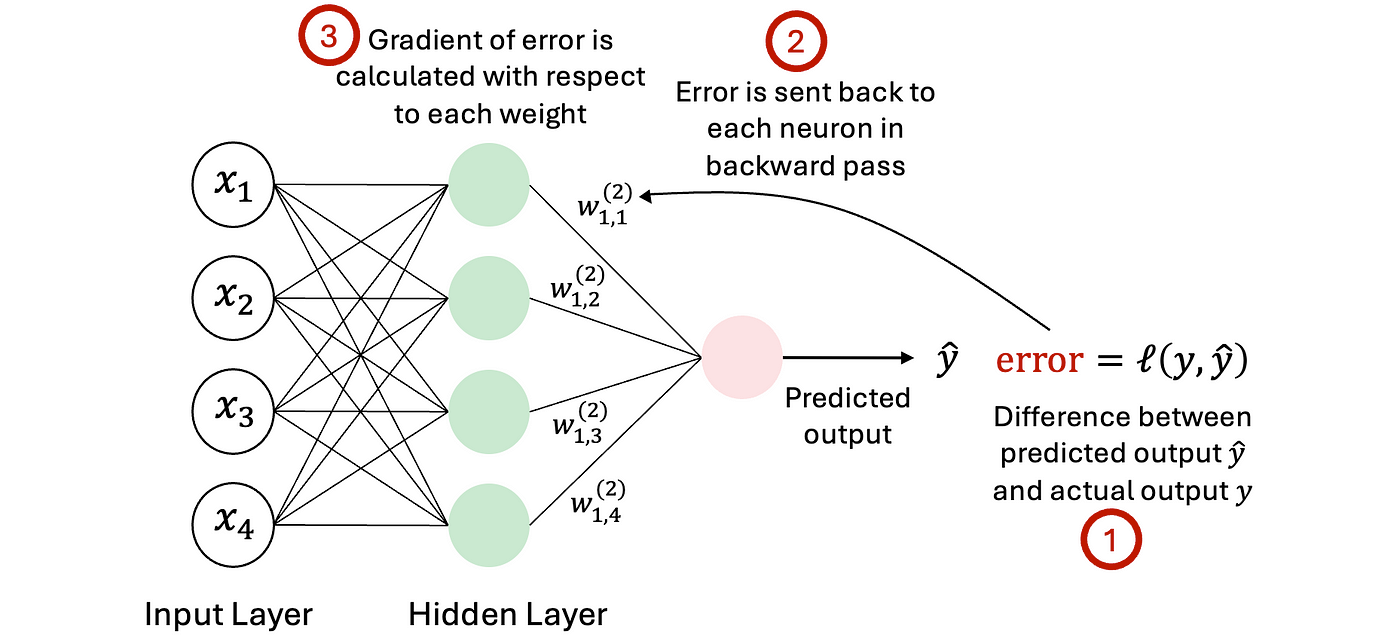

### The Core Mechanism: Matrix Chain Rule
Backpropagation relies on the **Multivariate Chain Rule** from calculus.
Since the output depends on intermediate layers—and those intermediate layers depend on earlier inputs—the error cannot be assigned directly. Instead, the error must be propagated backward layer by layer.
For a simple network:

- Input Layer → $l = 0$
- Hidden Layer → $l = 1$
- Output Layer → $l = 2$

the learning process starts from the final prediction error and moves backward through all layers.

### Phase 1 — Output Layer
After forward propagation, the network generates:
$$A^{(2)}=\hat{y}$$

This prediction is compared against the true label $Y$ using a Loss Function.
The first task is to determine how responsible the output neuron was for the final loss.

#### Step A — Compute Output Responsibility
The quantity:
$$dZ^{(2)}=\frac{\partial J}{\partial Z^{(2)}}$$
measures how changes in the output neuron’s pre-activation value affect total loss.
For the common combination:

- **Sigmoid Activation**
- **Binary Cross-Entropy Loss**

the derivative simplifies to:
$$dZ^{(2)}=A^{(2)}-Y$$

This simplification is extremely important.
The output responsibility becomes simply:

**Prediction − Ground Truth**
If the prediction was too high, the gradient becomes positive.
If the prediction was too low, the gradient becomes negative.

Dimensions:
$$(1\times1)$$

#### Step B — Compute Output Gradients
Once responsibility is known, we calculate how the output weights and biases should change.
The gradient for the weights is:
$$dW^{(2)}=
\frac{\partial J}{\partial W^{(2)}}=
dZ^{(2)}\cdot A^{(1)^T}$$

The gradient for the bias is:
$$db^{(2)}=
\frac{\partial J}{\partial b^{(2)}}=
\text{sum}(dZ^{(2)})$$

Interpretation:

- Large gradient → large correction
- Small gradient → small correction

Dimensions:
$$(1\times1)\cdot(1\times3)^T
\rightarrow
(1\times3)$$

matching $W^{(2)}$.

### Phase 2 — Backpropagating Through Activation Functions
The output gradients are not enough.
The error must continue backward through the hidden layer.
However, hidden neurons passed through a non-linear activation function (commonly ReLU), so the error must pass through that transformation.

#### Step C — Compute Hidden Responsibility

Now we determine:
$$dZ^{(1)}$$

which measures how responsible each hidden neuron was for the final prediction error.
This happens in two stages.

* **1. Transport the Error Backward**
Move the output error through the output weights:
$$W^{(2)^T}\cdot dZ^{(2)}$$

The transpose redirects influence backward.

* **2. Apply the Activation Derivative**

Each hidden neuron only receives error if it was active during forward propagation.

For ReLU:
$$f'(Z)=
\begin{cases}
1,& Z>0\\
0,& Z\le0 \end{cases}$$

The complete expression becomes:
$$dZ^{(1)}=\left(W^{(2)^T} \cdot dZ^{(2)} \right) * f'^{(1)}(Z^{(1)})$$

where: $*$ represents **element-wise multiplication**.

Dimensions:
$$(3\times1)\cdot(1\times1) \rightarrow (3\times1)$$


#### Intuition: ReLU as an Error Gate

ReLU behaves like a switch.
- If a hidden neuron produced a positive value → error flows backward.
- If a hidden neuron output zero → error is blocked.
This means inactive neurons do not learn during that update.
This phenomenon is known as the **dead ReLU problem**.

### Phase 3 — Compute Gradients for the First Layer
At this stage we know the hidden responsibilities.
Now we calculate how the original input weights should change.

#### Step D — Compute Input Gradients
The equations mirror Step B.

Weight gradients:
$$dW^{(1)}= \frac{\partial J}{\partial W^{(1)}}= dZ^{(1)} \cdot A^{(0)^T}$$

Bias gradients:
$$db^{(1)}= \frac{\partial J}{\partial b^{(1)}}= \text{sum}(dZ^{(1)})$$
where:
$$A^{(0)}=[x_1,x_2]$$

These gradients determine how the network should reinterpret the original inputs.
Dimensions:
$$(3\times1)\cdot(1\times2)^T \rightarrow (3\times2)$$

matching $$W^{(1)}$$.

### Final Step — Parameter Update
Backpropagation ends once all gradients have been calculated:
$$dW^{(1)}, db^{(1)}, dW^{(2)}, db^{(2)}$$

These values are passed to an optimizer.
For **Gradient Descent**, updates are:

Weights:
$$W=W-\eta dW$$

Biases:
$$b=b-\eta db$$

where:
$$\eta$$

is the **learning rate**.
The learning rate controls how aggressively the model updates itself.
After updating parameters:

1. Forward pass runs again
2. New predictions are generated
3. Error is measured
4. Backpropagation repeats

This cycle continues until the loss converges.

####  Summary

Backpropagation follows four repeated operations:

1. Compute output error
2. Propagate error backward
3. Compute local gradients
4. Update parameters

In compact form:
$$\text{Prediction} \rightarrow \text{Loss} \rightarrow \text{Gradients} \rightarrow \text{Update}$$

This feedback loop is what transforms a neural network from random guessing into a model capable of learning complex patterns.


#### Understanding Check

Consider a hidden neuron:
$$Z_1^{(1)}=-0.5$$

Since ReLU was used:

$$\text{ReLU}(-0.5)=0$$

Suppose the incoming error signal is:
$$W^{(2)^T}\cdot dZ^{(2)}=0.8$$

Since:
$$f'(Z_1^{(1)})=0$$

the final responsibility becomes:
$dZ_1^{(1)}=0.8\times0=0$

The neuron receives **no gradient update**.

This hidden neuron was inactive, so no learning occurs for it during this iteration.

--- 
## 6. Python Sandbox: Multi-Layer Perceptron for XOR Optimization

The code cell below implements a complete Multilayer Perceptron utilizing NumPy matrix mechanics. It includes both **Forward Propagation** and **Backpropagation** (via Gradient Descent) to solve the non-linearly separable XOR problem.

*For the XOR problem, refer to the "The Geometric View & Linear Separability" topic in the [Introduction to Neural Networks notebook](1_perceptron.ipynb)*.

### Matrix Layout for the XOR Network
* **Input to Hidden Layer ($W^{[1]}$):** A $(3 \times 2)$ shape matrix mapping 2 incoming raw features into 3 independent hidden neurons.
* **Hidden to Output Layer ($W^{[2]}$):** A $(1 \times 3)$ shape matrix mapping the 3 hidden activations into 1 final prediction value.

In [8]:
import numpy as np

class MultilayerPerceptron:
    def __init__(self, input_dim=2, hidden_dim=3, output_dim=1, lr=0.1):
        """
        Initialize weights and biases for a 2-layer network (input → hidden → output).
        Dimensions follow the matrix notation from Section 3.
        """
        np.random.seed(42)  # For reproducible results
        
        # Layer 1: Input → Hidden
        # W^[1] shape: (hidden_dim=3, input_dim=2) → Each row is a neuron's weight vector
        # This matches the matrix notation: W^[l+1] has shape (n^[l+1], n^[l])
        self.W1 = np.random.randn(hidden_dim, input_dim) * 0.1
        
        # b^[1] shape: (hidden_dim=3, 1) → One bias scalar per hidden neuron
        self.b1 = np.zeros((hidden_dim, 1))
        
        # Layer 2: Hidden → Output
        # W^[2] shape: (output_dim=1, hidden_dim=3) → Single output neuron with 3 weights
        self.W2 = np.random.randn(output_dim, hidden_dim) * 0.1
        
        # b^[2] shape: (output_dim=1, 1) → One bias for the output neuron
        self.b2 = np.zeros((output_dim, 1))
        
        self.lr = lr
 
    def relu(self, Z):
        """Non-linear activation function for hidden layer (Section 2)."""
        return np.maximum(0, Z)
 
    def relu_derivative(self, Z):
        """ReLU derivative for backpropagation (Section 5, Phase 2)."""
        return (Z > 0).astype(float)
 
    def sigmoid(self, Z):
        """Sigmoid activation for output layer (produces probability 0-1 for binary classification)."""
        return 1 / (1 + np.exp(-Z))
 
    def sigmoid_derivative(self, A):
        """Derivative of sigmoid in terms of its output A."""
        return A * (1 - A)
 
    def forward(self, X):
        """
        Forward propagation: Compute predictions layer-by-layer (Section 2).
        X shape: (input_dim, batch_size) → Each column is one training sample
        """
        # --- Layer 1: Hidden Layer ---
        # Z^[1] = W^[1] · a^[0] + b^[1]
        # This computes the weighted sum (linear step) for all 3 hidden neurons in parallel
        self.Z1 = np.dot(self.W1, X) + self.b1  # shape: (3, batch_size)
        
        # a^[1] = ReLU(Z^[1]) (non-linear step)
        # ReLU "folds" or "bends" the space, enabling non-linear learning
        self.A1 = self.relu(self.Z1)  # shape: (3, batch_size)
        
        # --- Layer 2: Output Layer ---
        # Z^[2] = W^[2] · a^[1] + b^[2]
        # Single output neuron combines the 3 hidden activations
        self.Z2 = np.dot(self.W2, self.A1) + self.b2  # shape: (1, batch_size)
        
        # a^[2] = Sigmoid(Z^[2])
        # Sigmoid squashes output to [0,1] for binary classification probability
        self.A2 = self.sigmoid(self.Z2)  # shape: (1, batch_size)
        
        return self.A2
 
    def backward(self, X, Y):
        """
        Backpropagation: Compute gradients for all weights and biases (Section 5).
        Gradients flow backward: Output → Hidden → Input
        """
        m = X.shape[1]  # Number of training samples (for averaging gradients)
        
        # ==================== PHASE 1: Output Layer ====================
        # Step A: Compute output responsibility (how much did output contribute to loss?)
        # For Sigmoid + Binary Cross-Entropy: dZ^[2] = A^[2] - Y
        # This simplifies to: Prediction - Ground Truth (Section 5, Phase 1)
        dZ2 = self.A2 - Y  # shape: (1, batch_size)
        
        # Step B: Compute gradients for W^[2] and b^[2]
        # dW^[2] = (1/m) · dZ^[2] · (a^[1])^T
        # Each output weight's gradient shows how much that input contributed to error
        dW2 = (1 / m) * np.dot(dZ2, self.A1.T)  # shape: (1, 3)
        
        # db^[2] = (1/m) · sum(dZ^[2])
        # Bias gradient is the average error signal
        db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)  # shape: (1, 1)
        
        # ==================== PHASE 2: Backpropagating Through Activation ====================
        # Step C: Compute hidden layer responsibility
        # First, transport error backward through weights: W^[2]^T · dZ^[2]
        dA1 = np.dot(self.W2.T, dZ2)  # shape: (3, batch_size)
        
        # Then apply ReLU derivative: multiply by 1 if Z^[1] > 0, else 0
        # This gates the error: inactive neurons (ReLU=0) don't learn in this iteration
        # This is the "dead ReLU problem" mentioned in Section 5
        dZ1 = dA1 * self.relu_derivative(self.Z1)  # shape: (3, batch_size)
        
        # ==================== PHASE 3: Compute Gradients for Hidden Layer ====================
        # Step D: Gradients for W^[1] and b^[1]
        # dW^[1] = (1/m) · dZ^[1] · (a^[0])^T  where a^[0] = X (raw inputs)
        dW1 = (1 / m) * np.dot(dZ1, X.T)  # shape: (3, 2)
        
        # db^[1] = (1/m) · sum(dZ^[1])
        db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)  # shape: (3, 1)
        
        # ==================== Final Step: Parameter Update (Gradient Descent) ====================
        # Update rule: W = W - η · dW  (Section 5, Final Step)
        # Learning rate (η) controls how aggressively we step toward lower loss
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
 
    def compute_loss(self, A2, Y):
        """
        Binary Cross-Entropy loss (Section 4).
        Measures how much the predictions diverge from true labels.
        Lower loss = better predictions.
        """
        m = Y.shape[1]
        # L = -(1/m) · Σ [y·log(ŷ) + (1-y)·log(1-ŷ)]
        # Added epsilon (1e-15) prevents log(0) = undefined
        loss = - (1 / m) * np.sum(Y * np.log(A2 + 1e-15) + (1 - Y) * np.log(1 - A2 + 1e-15))
        return loss
 
# --- Execution ---
if __name__ == "__main__":
    # XOR Problem: Learn a non-linearly separable boundary
    # A single perceptron cannot solve XOR (see Section 1_perceptron.ipynb)
    # But an MLP with hidden layers can!
    
    # X shape: (2, 4) → 2 input features, 4 training samples
    # Each column represents one (x1, x2) pair
    X = np.array([[0, 0, 1, 1],
                  [0, 1, 0, 1]])
    
    # Y shape: (1, 4) → 1 output (binary classification), 4 targets
    # XOR truth table: (0,0)→0, (0,1)→1, (1,0)→1, (1,1)→0
    Y = np.array([[0, 1, 1, 0]])
 
    # Instantiate the network
    # Hidden layer has 3 neurons to create a non-linear decision boundary
    mlp = MultilayerPerceptron(input_dim=2, hidden_dim=3, output_dim=1, lr=0.5)
    
    print("Training the Multilayer Perceptron on XOR...")
    print("The network learns to bend 2D space through hidden neurons,")
    print("then draws a new linear boundary in the bent space.\n")
    
    # Training loop: Forward pass → Compute loss → Backpropagation → Update
    for epoch in range(1000):
        # Forward: X → Hidden (3 neurons) → Output
        predictions = mlp.forward(X)
        
        # Compute loss to track learning progress
        loss = mlp.compute_loss(predictions, Y)
        
        # Backward: Calculate gradients and update weights (learning cycle)
        mlp.backward(X, Y)
        
        if (epoch + 1) % 200 == 0:
            print(f"Epoch {epoch + 1}/1000 - Loss: {loss:.4f}")
            
    # Final verification
    final_preds = mlp.forward(X)
    print("\nFinal Trained Predictions:")
    print("The network has learned the XOR pattern:")
    for i in range(4):
        print(f"Input: [{X[0,i]}, {X[1,i]}] → Predicted: {final_preds[0,i]:.4f} (Target: {Y[0,i]})")

Training the Multilayer Perceptron on XOR...
The network learns to bend 2D space through hidden neurons,
then draws a new linear boundary in the bent space.

Epoch 200/1000 - Loss: 0.0634
Epoch 400/1000 - Loss: 0.0138
Epoch 600/1000 - Loss: 0.0074
Epoch 800/1000 - Loss: 0.0050
Epoch 1000/1000 - Loss: 0.0037

Final Trained Predictions:
The network has learned the XOR pattern:
Input: [0, 0] → Predicted: 0.0062 (Target: 0)
Input: [0, 1] → Predicted: 0.9987 (Target: 1)
Input: [1, 0] → Predicted: 0.9987 (Target: 1)
Input: [1, 1] → Predicted: 0.0062 (Target: 0)
